Ce notebook va être consacré au preprocessing du dataset et l'entrainement d'un premier modèle simple pour établir une baseline.

---

# Load

In [1]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

# pandas display options
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

random_state = 42
np.random.seed(random_state)
tf.random.set_seed(random_state)

base_path = 'data'
file_name = 'season.csv'
years = range(2019, 2023)
seq_len = 5


In [2]:
from f1pitpred.loading import load_from_csv

data = load_from_csv(years)

# Preprocessing

In [27]:
from f1pitpred.preprocessing import get_preprocessed_sequences


X_train, y_train, X_test, y_test, encoder = get_preprocessed_sequences(
    data,
    0.2,
    seq_len,
    random_state=random_state,
    target='tire',
    drop=True
)

In [4]:
y_train.shape, X_train.shape

((1487, 3), (1487, 5, 47))

# Modelisation

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix

import tensorflow.keras.backend as K

def balanced_accuracy(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)
    sensitivity = tp / (tp + fn)
    return (specificity + sensitivity) / 2

def balanced_accuracy_loss(y_true, y_pred):
    tp = K.sum(y_true * y_pred)
    tn = K.sum((1 - y_true) * (1 - y_pred))
    fp = K.sum((1 - y_true) * y_pred)
    fn = K.sum(y_true * (1 - y_pred))
    specificity = tn / (tn + fp + K.epsilon())
    sensitivity = tp / (tp + fn + K.epsilon())
    return specificity + sensitivity / 2

In [32]:
y_ints = [y.argmax() for y in y_train]

In [36]:
np.unique(y_ints, return_counts=True)

(array([0, 1, 2], dtype=int64), array([672, 496, 319], dtype=int64))

In [6]:
y_ints = [y.argmax() for y in y_train]
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_ints),
    y=y_ints)

class_weights_dict = dict(enumerate(class_weights))
class_weights_dict

{0: 0.7375992063492064, 1: 0.9993279569892473, 2: 1.553814002089864}

In [7]:
from keras.regularizers import l2
from keras.optimizers import Nadam
from tensorflow import keras
from tensorflow.keras import layers
from keras.optimizers import Adam
from keras.metrics import categorical_accuracy

In [8]:
model = keras.Sequential()
model.add(layers.LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2]), return_sequences=True))
model.add(layers.Dropout(0.1))
model.add(layers.LSTM(64))
model.add(layers.Dropout(0.1))
model.add(layers.Dense(64, activation='relu', kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(layers.Dropout(0.1))
model.add(layers.Dense(64, activation='relu', kernel_regularizer=l2(0.01), bias_regularizer=l2(0.01)))
model.add(layers.Dropout(0.1))
model.add(layers.Dense(3, activation='softmax'))
optimizer = Nadam(
    learning_rate=0.00005,
)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=[categorical_accuracy],
    )

In [9]:
from keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True,
    verbose=1,
    mode='min',
)

hist = model.fit(
    X_train,
    y_train,
    batch_size=32,
    epochs=300,
    callbacks=[early_stopping],
    validation_data=(X_test, y_test),
    verbose=1,    
)

Epoch 1/300
47/47 [==============================] - 11s 48ms/step - loss: 2.3562 - categorical_accuracy: 0.3477 - val_loss: 2.3255 - val_categorical_accuracy: 0.4545
Epoch 2/300
47/47 [==============================] - 1s 16ms/step - loss: 2.3126 - categorical_accuracy: 0.4230 - val_loss: 2.2827 - val_categorical_accuracy: 0.4716
Epoch 3/300
47/47 [==============================] - 1s 14ms/step - loss: 2.2710 - categorical_accuracy: 0.4472 - val_loss: 2.2427 - val_categorical_accuracy: 0.4659
Epoch 4/300
47/47 [==============================] - 1s 14ms/step - loss: 2.2328 - categorical_accuracy: 0.4539 - val_loss: 2.2037 - val_categorical_accuracy: 0.4659
Epoch 5/300
47/47 [==============================] - 1s 14ms/step - loss: 2.1950 - categorical_accuracy: 0.4573 - val_loss: 2.1658 - val_categorical_accuracy: 0.4659
Epoch 6/300
47/47 [==============================] - 1s 16ms/step - loss: 2.1581 - categorical_accuracy: 0.4499 - val_loss: 2.1283 - val_categorical_accuracy: 0.4659
Epo

In [10]:
y_pred = model.predict(X_test)

11/11 [==============================] - 2s 5ms/step


In [48]:
y_pred = model.predict(X_test)
y_pred_res = np.argmax(y_pred, axis=1)
y_test_res = np.argmax(y_test, axis=1)

11/11 [==============================] - 0s 7ms/step


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test_res, y_pred_res, zero_division=0))

              precision    recall  f1-score   support

           0       0.73      0.74      0.73       164
           1       0.50      0.50      0.50       115
           2       0.64      0.59      0.61        73

    accuracy                           0.63       352
   macro avg       0.62      0.61      0.62       352
weighted avg       0.63      0.63      0.63       352



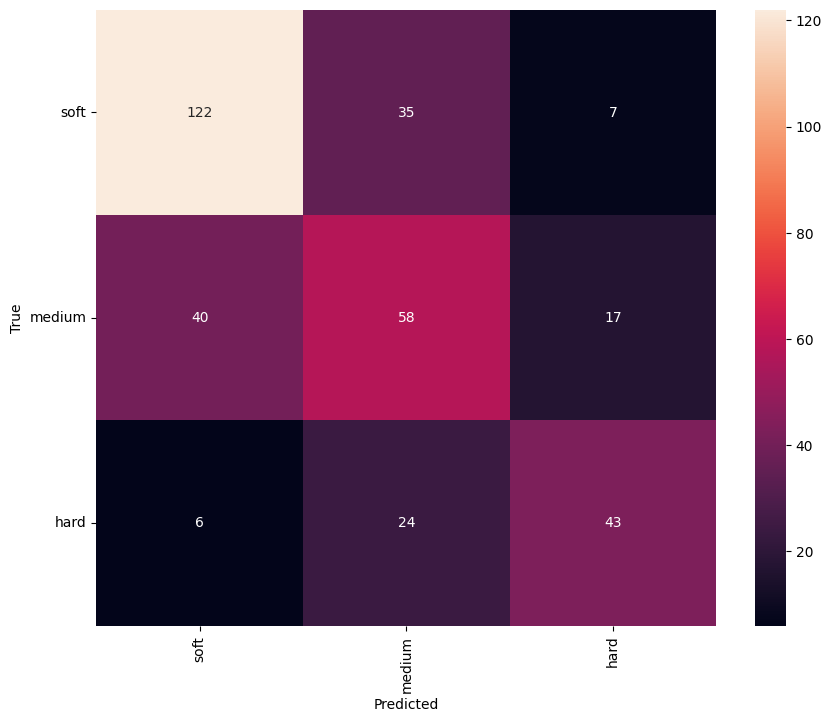

In [49]:
from sklearn.metrics import classification_report, multilabel_confusion_matrix, confusion_matrix
#print(multilabel_confusion_matrix(y_test, y_pred))
#print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test_res, y_pred_res)
labels = ['soft', 'medium', 'hard']
class_names = labels
# Plot confusion matrix in a beautiful manner
fig = plt.figure(figsize=(10, 8))
ax= plt.subplot()
sns.heatmap(cm, annot=True, ax = ax, fmt = 'g'); #annot=True to annotate cells
# labels, title and ticks
ax.set_xlabel('Predicted', fontsize=10)
ax.xaxis.set_label_position('bottom')
plt.xticks(rotation=90)
ax.xaxis.set_ticklabels(class_names, fontsize = 10)
ax.xaxis.tick_bottom()

ax.set_ylabel('True', fontsize=10)
ax.yaxis.set_ticklabels(class_names, fontsize = 10)
plt.yticks(rotation=0)
plt.savefig('confusion_matrix_tire.svg', format='svg')

In [13]:
import pickle
# Save model
models_dir = 'models/rnn_tire'
os.makedirs(models_dir, exist_ok=True)
model.save(os.path.join(models_dir, 'model.h5'))
encoder_path = os.path.join(models_dir, 'encoder.pkl')
with open(encoder_path, 'wb') as f:
    pickle.dump(encoder, f)

C:\Users\Nelson Jeanrenaud\AppData\Roaming\Python\Python311\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [3]:
import pickle
models_dir = 'models/rnn_tire'
encoder_path = os.path.join(models_dir, 'encoder.pkl')
from tensorflow.keras.models import load_model
model = load_model(os.path.join(models_dir, 'model.h5'), compile=False)
encoder = pickle.load(open(encoder_path, 'rb'))

In [56]:
validation_data = load_from_csv([2023], base_path, "azerbaijan_grand_prix.csv")

validation_data = validation_data[validation_data['DriverNumber'] == '11']
from f1pitpred.preprocessing import get_preprocessed_sequences_new
validation_x, cols = get_preprocessed_sequences_new(validation_data, encoder, 5, target='tire')
proba = model.predict(np.array(validation_x).astype('float32'))

from f1pitpred.preprocessing import preprocess_new_data, get_x_y_tires
validation_df = preprocess_new_data(validation_data, encoder, target='tire')
x, y = get_x_y_tires(validation_df)

2/2 [==============================] - 0s 23ms/step


In [57]:
# adds [0,0,0] to the start of the proba array to make it the same length as the y array
while len(proba) < len(y):
    proba = np.insert(proba, 0, [0,0,0], axis=0)

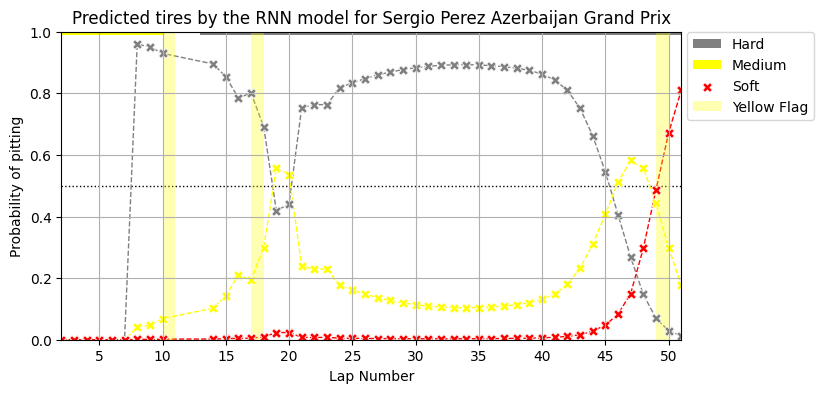

In [59]:
from f1pitpred.plotting import plot_remove_duplicate_legends

def plot_race_predictions(x, y, proba, ax, colors=['red', 'yellow', 'gray'], marker='X', labels=['Soft', 'Medium', 'Hard'], title='Predicted pitstops'):
    """
    Plot pitstop predictions for series of laps

    Parameters
    ----------
    x : pandas DataFrame
        A dataframe containing the following columns:
        - LapNumber
        - TotalLaps
    y : array-like
        The ground truth pitstop labels
    proba : array-like
        The predicted probability of pitting
    ax : matplotlib Axes
        The axes to plot on
    color : str, default 'cyan'
        The color of the plotted points
    marker : str, default 'X'
        The marker of the plotted points
    label : str, default 'Predicted pitstop'
        The label of the plotted points
    title : str, default 'Predicted pitstops'
        The title of the plot

    Returns
    -------
    ax : matplotlib Axes
        The axes with the plotted points
    """
    x['index'] = x['LapNumber']
    x = x.set_index('index')
    y.index = x.index

    ax.hlines(y=0.5, xmin=x['LapNumber'].min(), xmax=x['TotalLaps'].max(), linewidth=1, colors='black', linestyles='dotted', zorder=0)
    for i in range(len(labels)):
        sns.scatterplot(x=x['LapNumber'], y=proba[:, i], marker=marker, legend=False, ax=ax, s=50, label=labels[i], color=colors[i])
        sns.lineplot(x=x['LapNumber'], y=proba[:, i], linewidth=1, linestyle='dashed', zorder=0, ax=ax, color=colors[i])
    ax.set_xlabel('Lap Number')
    ax.set_xticks(np.arange(0, x['TotalLaps'].max(), 5))
    ax.set_ylim(0, 1)
    ax.set_ylabel('Probability of pitting')
    ax.set_xlim(x['LapNumber'].min(), x['TotalLaps'].max())    

    ax.set_title(title)
    return plot_remove_duplicate_legends(ax, loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0.)
from f1pitpred.plotting import plot_stoppages, plot_tyres

fig, ax = plt.subplots(figsize=(8, 4))
ax.grid()
plot_race_predictions(x, y, proba, ax, colors=['gray', 'yellow', 'red'], labels=['Hard', 'Medium', 'Soft'])
plot_stoppages(x, ax)
plot_tyres(x, ax)
plt.title('Predicted tires by the RNN model for Sergio Perez Azerbaijan Grand Prix')

plt.savefig('predictions_tire.svg', format='svg')